# Q-Learning con Variable Green Durations

s = (nvehicles, twaiting, lqueue, rarrival). Acciones: 12 duraciones de verde (5-60s).
Recompensa: multi-objetivo paper Electronics 2025 (sin clipping).

Configuracion:
- 5000 epocas, num_seconds=100000, delta_time=5
- Epsilon: 0.5 -> 0.05 con decay 0.9995 (por episodio)
- Sin clipping de recompensa
- Discretizador: 6/6/4/3 bins (288 estados x 12 acciones = 3456 total)
- Experience Replay: buffer=2000, batch=64, update_freq=4
- QLAgentConVisitas: tracking de visitas + early stopping por cobertura
- Guarda ultimo modelo

In [1]:
import os
os.environ["LIBSUMO_AS_TRACI"] = "1"

In [2]:
import traci

# Limpiar conexiones zombie de ejecuciones anteriores
try:
    traci.close()
except:
    pass

Using libsumo as traci as requested by environment variable.


In [3]:
import argparse
import pandas as pd
import pickle
import sys
import numpy as np
import gymnasium as gym
from sumo_rl import SumoEnvironment
from sumo_rl.agents import QLAgent
from sumo_rl.exploration import EpsilonGreedy
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
if 'SUMO_HOME' not in os.environ:
    os.environ['SUMO_HOME'] = '/usr/share/sumo'
tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
sys.path.append(tools)

In [5]:
NET = os.path.join("..", "Simple_Intersection.net.xml")
ROU = os.path.join("..", "Distribuciones", "loja_intersection_weibull.rou.xml")
OUT_FOLDER = "resultados"

os.makedirs(OUT_FOLDER, exist_ok=True)

print(f"NET existe: {os.path.exists(NET)}")
print(f"ROU existe: {os.path.exists(ROU)}")

NET existe: True
ROU existe: True


## Reward

Recompensa multi-objetivo basada en:
"Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban
Traffic Signal Control" (Electronics 2025, 14, 2759)
https://www.mdpi.com/2079-9292/14/14/2759

Componentes:
1. Penalizacion por tiempo de espera promedio (-2.0 * waiting_time)
2. Recompensa por throughput (+1.5 * vehicles_departed)
3. Recompensa por mejora en espera (+3.0 * improvement)
4. Penalizacion por congestion severa (-100.0 si waiting>9s AND queue>61)

Umbrales calibrados:
- waiting > 9s: promedio observado en baseline de tiempos fijos
- queue > 61: percentil 75 del baseline

In [6]:
class Reward:
    def __init__(self):
        self._prev = {'waiting': 0.0, 'veh_ids': set()}

    def reset(self):
        self._prev = {'waiting': 0.0, 'veh_ids': set()}

    def __call__(self, ts):
        ids = ts.sumo.vehicle.getIDList()
        waiting_time = np.mean([ts.sumo.vehicle.getWaitingTime(v) for v in ids]) if len(ids) > 0 else 0.0
        veh_ids_actuales = set(v for lane in ts.lanes for v in ts.sumo.lane.getLastStepVehicleIDs(lane))
        throughput = len(self._prev['veh_ids'] - veh_ids_actuales)
        queue = ts.get_total_queued()

        improvement = self._prev['waiting'] - waiting_time
        congestion = -100.0 if (waiting_time > 9 and queue > 61) else 0.0

        self._prev = {'waiting': waiting_time, 'veh_ids': veh_ids_actuales}
        return -2.0 * waiting_time + 1.5 * throughput + 3.0 * improvement + congestion

## VariableGreenWrapper

Seleccion de duracion de verde (5-60s en pasos de 5s) = 12 acciones.

Referencia:
- Paper original usa duraciones fijas de 45s. Este wrapper permite al agente
  seleccionar entre 12 duraciones (5, 10, 15, ..., 60 segundos).
- El wrapper alterna fases internamente (1 - fase_actual) y acumula
  recompensa durante la duracion seleccionada.

Por que 5-60s:
- Minimo 5s: tiempo minimo util para un ciclo de semaforo
- Maximo 60s: limite razonable para no bloquear interseccion
- Paso de 5s: balance entre granularidad y espacio de acciones

In [7]:
class VariableGreenWrapper(gym.Wrapper):
    DURACIONES = list(range(5, 65, 5))  # 12 acciones: 5-60s

    def __init__(self, env, delta_time=5):
        super().__init__(env)
        self.delta_time = delta_time
        self.action_space = gym.spaces.Discrete(len(self.DURACIONES))
        self._fase_actual = 0

    def step(self, action_idx):
        duracion = self.DURACIONES[action_idx]
        n_pasos = duracion // self.delta_time
        reward_acumulado = 0.0
        terminated = truncated = False
        info = {}
        for _ in range(n_pasos):
            obs, reward, terminated, truncated, info = self.env.step(self._fase_actual)
            reward_acumulado += reward
            if terminated or truncated:
                break
            if self.env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
                break
        self._fase_actual = 1 - self._fase_actual
        return obs, reward_acumulado, terminated, truncated, info

    def reset(self, **kwargs):
        self._fase_actual = 0
        return self.env.reset(**kwargs)

## ReplayBuffer

Buffer de experience replay para Q-learning.

En un enfoque Q-Learning en linea, la matriz Q se actualiza una sola vez por cada paso
de tiempo. Al incorporar el buffer, el agente almacena y reutiliza multiples veces las
transiciones previas, incrementando la eficiencia de datos (sample efficiency) y acelerando
la convergencia de la matriz Q al propagar la informacion de recompensa retrospectivamente
sobre estados de trafico visitados con poca frecuencia. La extraccion aleatoria rompe las
correlaciones temporales inherentes a las secuencias vehiculares, otorgando estabilidad
matematica al proceso de actualizacion.

Referencia:
- Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban Traffic
  Signal Control (Electronics 2025, 14, 2759)
  https://www.mdpi.com/2079-9292/14/14/2759
- Mnih et al. (2015) "Human-level control through deep reinforcement learning"
  https://www.nature.com/articles/nature14236

Implementacion:
- Capacidad maxima: 2000 experiencias (tuplas s, a, r, s')
- Mini-lote: 64 muestras extraidas aleatoriamente del buffer
- Muestreo por lotes permite reutilizar historial en multiples ciclos de actualizacion

In [8]:
class ReplayBuffer:
    def __init__(self, buffer_size=2000):
        self.buffer_size = buffer_size
        self.buffer = []
        self.position = 0
        self.total_pushes = 0
        self.total_samples = 0

    def push(self, state, action, reward, next_state, done):
        experience = (state, action, reward, next_state, done)
        if len(self.buffer) < self.buffer_size:
            self.buffer.append(experience)
        else:
            self.buffer[self.position] = experience
        self.position = (self.position + 1) % self.buffer_size
        self.total_pushes += 1

    def sample(self, batch_size=64):
        if len(self.buffer) < batch_size:
            return self.buffer
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        self.total_samples += batch_size
        return [self.buffer[i] for i in indices]

    def __len__(self):
        return len(self.buffer)

    def get_stats(self):
        if len(self.buffer) == 0:
            return {'size': 0, 'capacity': self.buffer_size, 'total_pushes': self.total_pushes}
        rewards = [exp[2] for exp in self.buffer]
        return {
            'size': len(self.buffer), 'capacity': self.buffer_size,
            'avg_reward': np.mean(rewards), 'min_reward': np.min(rewards), 'max_reward': np.max(rewards),
            'total_pushes': self.total_pushes
        }

## QLAgentWithReplay

El agente Q-Learning se estructura mediante una clase extendida que incorpora un mecanismo
de repeticion de experiencias. Durante la interaccion con el simulador, las transiciones
experimentadas por el agente (estado actual, accion ejecutada, recompensa recibida y
estado resultante) se almacenan secuencialmente en un buffer de memoria.

Hiperparametros de control:
- update_freq=4: la matriz Q se recalcula cada 4 pasos de simulacion.
  Limita las operaciones de iteracion sobre la memoria, disminuyendo el costo
  computacional del entrenamiento.
- batch_size=64: cuando se cumple la condicion de actualizacion, se extrae un lote
  aleatorio de 64 transiciones. La extraccion aleatoria reutiliza experiencias pasadas
  y rompe la correlacion temporal entre observaciones de trafico consecutivas,
  cumpliendo con el principio de independencia de muestras requerido para la
  actualizacion de la ecuacion de diferencia temporal.

Inicializacion dinamica de la matriz Q:
- Debido a que el entorno genera combinaciones de estados que no pueden predefinirse,
  la matriz Q se gestiona de forma dinamica.
- El metodo de verificacion evalua si un estado existe en la estructura de datos;
  en caso de ser un estado no visitado, inicializa sus valores Q en 0.0 para todo
  el espacio de acciones discreto.
- La dimensionalidad de la matriz se construye progresivamente en funcion de los
  estados efectivamente explorados.

Referencia:
- Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban Traffic
  Signal Control (Electronics 2025, 14, 2759)
  https://www.mdpi.com/2079-9292/14/14/2759
- QLAgent base: https://github.com/LucasFIEI/sumo-rl/blob/main/sumo_rl/agents/ql_agent.py

In [9]:
class QLAgentWithReplay(QLAgent):
    def __init__(self, starting_state, state_space, action_space,
                 alpha, gamma, exploration_strategy,
                 replay_buffer, batch_size=64, update_freq=4):
        super().__init__(starting_state, state_space, action_space,
                        alpha, gamma, exploration_strategy)
        self.replay_buffer = replay_buffer
        self.batch_size = batch_size
        self.update_freq = update_freq
        self.step_count = 0

    def _ensure_state_in_qtable(self, state):
        s = tuple(state) if hasattr(state, '__iter__') else state
        if s not in self.q_table:
            self.q_table[s] = [0.0] * self.action_space.n
        return s

    def act(self):
        self._ensure_state_in_qtable(self.state)
        return super().act()

    def learn_with_replay(self, next_state, reward, done):
        self.replay_buffer.push(self.state, self.action, reward, next_state, done)
        self.state = next_state
        self.step_count += 1
        if len(self.replay_buffer) >= self.batch_size and self.step_count % self.update_freq == 0:
            batch = self.replay_buffer.sample(self.batch_size)
            for state, action, reward, next_state, done in batch:
                self._update_q(state, action, reward, next_state, done)

    def _update_q(self, state, action, reward, next_state, done):
        s = self._ensure_state_in_qtable(state)
        ns = self._ensure_state_in_qtable(next_state)
        target = reward if done else reward + self.gamma * max(self.q_table[ns])
        self.q_table[s][action] += self.alpha * (target - self.q_table[s][action])

## QLAgentConVisitas

Extension de QLAgentWithReplay con conteo de visitas por estado.

Proposito:
- Rastrear cuantas veces visita el agente cada estado
- Usado para early stopping: detener entrenamiento cuando cobertura se estabiliza
- Permite analizar que estados explora el agente durante el entrenamiento

In [10]:
class QLAgentConVisitas(QLAgentWithReplay):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.visitas = {}

    def act(self):
        estado = tuple(self.state) if hasattr(self.state, '__iter__') else self.state
        self.visitas[estado] = self.visitas.get(estado, 0) + 1
        return super().act()

## TrafficStateWrapper

Para la implementacion del agente Q-Learning Tabular, la formulacion del espacio de estados
requiere una discretizacion matematica rigurosa. A diferencia de las redes neuronales
profundas (DQN) que procesan variables continuas y generalizan patrones de entrada, el
algoritmo Q-Learning tradicional actualiza una matriz finita de valores estado-accion.
Un espacio de estados continuo o excesivamente particionado genera un crecimiento exponencial
de la matriz Q, impidiendo la convergencia del agente.

El codigo implementado en la clase TrafficStateWrapper emplea un enfoque de discretizacion
multidimensional estructurado y validado en la literatura de control semaforico. El estado
continuo del entorno se transforma mediante una envoltura de Gymnasium en una tupla discreta
de cuatro dimensiones St = (Nt, Wt, Qt, At), mapeada en un espacio discreto MultiDiscrete().

Componentes:
- Numero de vehiculos activos (Nt) [6 bins]: Cuantifica la densidad absoluta del entorno
  evaluando la lista de identificadores vehiculares en curso. La division en 6 intervalos
  captura las transiciones de densidad, diferenciando los flujos bajos donde cambios minimos
  afectan el trafico, de los escenarios de alto volumen.
- Tiempo de espera promedio (Wt) [6 bins]: Calcula la media del tiempo de espera de los
  vehiculos activos. Esta resolucion de 6 categorias provee resolucion suficiente para
  detectar cruces de umbrales criticos en la demora vehicular sin expandir el estado.
- Longitud de cola (Qt) [4 bins]: Mide la congestion fisica registrando los vehiculos
  detenidos (umbral de velocidad < 0.1 m/s). La discretizacion en 4 niveles sintetiza de
  forma efectiva la dinamica espacial de acumulacion en los carriles.
- Tasa de llegada (At) [3 bins]: Calcula el flujo de ingreso vehicular mediante una ventana
  de tiempo movil de 30 segundos, correspondiente a 6 pasos de simulacion (delta_time de
  5 segundos). Restringirlo a 3 bins minimiza representaciones redundantes ante llegadas
  estocasticas.

La matriz parametrica de 6x6x4x3 limita el tamano del entorno a exactamente 432 estados
discretos. Evaluaciones empiricas en la literatura demuestran que configuraciones de mayor
granularidad (como 8/8/6/5 bins) incrementan el espacio en mas de un 300%, penalizando
drasticamente la tasa de convergencia del aprendizaje sin otorgar ventajas significativas
en el control. Esta topologia dimensional constituye el punto de equilibrio optimo entre
la captura de dinamicas de trafico complejas y la eficiencia computacional.

Calibracion de bin edges:
- Los limites numericos de particion no se programan de manera estatica.
- Se aplican los valores parametricos guardados en bin_edges_calibrados.npz,
  extraidos estadisticamente a partir de los percentiles de distribucion de la
  simulacion de linea base (tiempos fijos).
- En cada iteracion temporal, la funcion np.digitize mapea las variables continuas
  extraidas de la API de TraCI hacia estos indices calibrados.
- Este metodo garantiza que las fronteras de discretizacion esten matematicamente
  adaptadas a la demanda especifica de la interseccion evaluada en Loja.

Referencia:
- Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban Traffic
  Signal Control (Electronics 2025, 14, 2759)
  https://www.mdpi.com/2079-9292/14/14/2759
- A Deep Adaptive Traffic Signal Controller With Long-Term Planning Horizon and
  Spatial-Temporal State Definition Under Dynamic Traffic Fluctuations
  https://doi.org/10.3390/app14041531

In [ ]:
_edges = np.load("../Simulaciones_tiempos_fijos/resultados/bin_edges_calibrados.npz")
EDGES_NVEHICULOS = _edges["nvehiculos"]
EDGES_WAITING    = _edges["waiting"]
EDGES_QUEUE      = _edges["queue"]
EDGES_ARRIVAL    = _edges["arrival"]


class TrafficStateWrapper(gym.Wrapper):
    observation_space = gym.spaces.MultiDiscrete([6, 6, 4, 3])

    def _compute_state(self):
        ids = self.env.unwrapped.sumo.vehicle.getIDList()
        n_vehiculos = len(ids)
        waiting = np.mean([self.env.unwrapped.sumo.vehicle.getWaitingTime(v) for v in ids]) if n_vehiculos > 0 else 0.0
        queue = self.env.unwrapped.traffic_signals[self.env.unwrapped.ts_ids[0]].get_total_queued()

        if not hasattr(self, '_ventana_llegadas'):
            self._ventana_llegadas = []
        arrival_step = self.env.unwrapped.sumo.simulation.getDepartedNumber()
        self._ventana_llegadas.append(arrival_step)
        if len(self._ventana_llegadas) > 6:
            self._ventana_llegadas.pop(0)
        arrival = sum(self._ventana_llegadas)

        bin_n = int(np.digitize(n_vehiculos, EDGES_NVEHICULOS))
        bin_w = int(np.digitize(waiting, EDGES_WAITING))
        bin_q = int(np.digitize(queue, EDGES_QUEUE))
        bin_a = int(np.digitize(arrival, EDGES_ARRIVAL))

        return (bin_n, bin_w, bin_q, bin_a)

    def reset(self, **kwargs):
        self._ventana_llegadas = []
        obs, info = self.env.reset(**kwargs)
        return self._compute_state(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._compute_state(), reward, terminated, truncated, info

In [ ]:
def get_args():
    """
    Parametros de entrenamiento Q-Learning con referencias bibliograficas.
    
    Referencias:
    - Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban Traffic
      Signal Control (Electronics 2025, 14, 2759)
    # Asegura convergencia manteniendo viabilidad computacional.   https://www.mdpi.com/2079-9292/14/14/2759
    """
    prs = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter)
    prs.add_argument("-route", dest="route", type=str, default=ROU)
    prs.add_argument("-net", dest="net", type=str, default=NET)

    # Alpha (learning rate): tasa de aprendizaje para la actualizacion de la matriz Q.
    # Controla la magnitud de las actualizaciones de los valores estado-accion.
    # Ref: Comparative Evaluation of Fuzzy Logic and Q-Learning (2025)
    prs.add_argument("-a", dest="alpha", type=float, default=0.1)

    # Gamma (discount factor): factor de descuento para recompensas futuras.
    # Un valor de 0.95 prioriza recompensas a corto plazo manteniendo visibilidad
    # de consecuencias futuras en el trafico.
    # Ref: Comparative Evaluation of Fuzzy Logic and Q-Learning (2025)
    prs.add_argument("-g", dest="gamma", type=float, default=0.95)
    prs.add_argument("-gui", action="store_true", default=False)
    prs.add_argument("-r", dest="reward", type=str, default='paper_2025')

    # Runs: numero de ejecuciones independientes del experimento.
    prs.add_argument("-runs", dest="runs", type=int, default=1)

    # Episodes: 5000 episodios de entrenamiento.
    # Suficiente para alcanzar convergencia de la politica con Experience Replay.
    # Ref: Comparative Evaluation of Fuzzy Logic and Q-Learning (2025)
    prs.add_argument("-episodes", dest="episodes", type=int, default=5000)
    prs.add_argument("-num_seconds", dest="num_seconds", type=int, default=100000)

    # Min epsilon: umbral minimo de exploracion (5%).
    # Previene convergencia a optimos locales manteniendo adaptabilidad.
    prs.add_argument("-min_epsilon", dest="min_epsilon", type=float, default=0.05)

    # Initial epsilon: exploracion inicial al 50%.
    # Politica epsilon-greedy que guia desde exploracion hacia explotacion.
    prs.add_argument("-initial_epsilon", dest="initial_epsilon", type=float, default=0.5)

    # Decay: decaimiento de epsilon por episodio (0.9995).
    # Reduce exploracion gradualmente a lo largo de los 5000 episodios.
    prs.add_argument("-decay", dest="decay", type=float, default=0.9995)
    return prs.parse_args(args=[])

In [9]:
if __name__ == '__main__':
    if 'args' not in dir():
        args = get_args()

    exploracion = EpsilonGreedy(
        initial_epsilon=args.initial_epsilon,
        min_epsilon=args.min_epsilon,
        decay=1.0  # sin decay interno, solo el loop controla por episodio
    )

    replay_buffer = ReplayBuffer(buffer_size=2000)
    reward_fn = Reward()

    import sys as _sys
    import os as _os

    historial_recompensas = []
    cobertura_historial = []

    def cobertura_estabilizada(historial, ventana=5):
        return len(historial) >= ventana and historial[-1] <= historial[-ventana]

    print("Entrenamiento Q-Learning (12 duraciones de verde, reward paper 2025)...")
    for run in range(1, args.runs + 1):
        for episode in range(1, args.episodes + 1):
            reward_fn.reset()

            _old_stderr = _sys.stderr
            _sys.stderr = open(_os.devnull, 'w')

            env = SumoEnvironment(
                net_file=args.net,
                route_file=args.route,
                out_csv_name="temp",
                single_agent=True,
                use_gui=args.gui,
                num_seconds=args.num_seconds,
                delta_time=5,
                yellow_time=3,
                min_green=5,
                reward_fn=reward_fn,
                time_to_teleport=-1,
                additional_sumo_cmd="-W --no-step-log"
            )

            _sys.stderr = _old_stderr

            env = VariableGreenWrapper(env, delta_time=5)
            env = TrafficStateWrapper(env)
            obs, _ = env.reset()

            if episode == 1 and run == 1:
                agente = QLAgentConVisitas(
                    starting_state=obs,
                    state_space=env.observation_space,
                    action_space=env.action_space,
                    alpha=args.alpha,
                    gamma=args.gamma,
                    exploration_strategy=exploracion,
                    replay_buffer=replay_buffer,
                    batch_size=64,
                    update_freq=4
                )

            try:
                agente.state = obs
                done = False
                recompensa_episodio = 0

                tiempo_final = 0
                while not done:
                    accion = agente.act()
                    next_obs, reward, terminated, truncated, info = env.step(accion)

                    agente.learn_with_replay(next_state=next_obs, reward=reward, done=terminated)
                    recompensa_episodio += reward

                    if env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
                        tiempo_final = env.unwrapped.sim_step
                        break

                    done = terminated or truncated

                historial_recompensas.append(recompensa_episodio)

            finally:
                env.close()

            exploracion.epsilon = max(exploracion.epsilon * args.decay, args.min_epsilon)

            if episode % 100 == 0:
                cobertura = len(agente.q_table) / (6 * 6 * 4 * 3)
                cobertura_historial.append(cobertura)
                print(f"  Ep {episode:03d} | Rec: {recompensa_episodio:10.2f} | Epsilon: {exploracion.epsilon:.3f} | Vaciado: {tiempo_final:.0f}s | Cobertura: {cobertura:.1%}")
            else:
                print(f"  Ep {episode:03d} | Rec: {recompensa_episodio:10.2f} | Epsilon: {exploracion.epsilon:.3f} | Vaciado: {tiempo_final:.0f}s")

            if cobertura_estabilizada(cobertura_historial):
                print(f"Cobertura estabilizada en episodio {episode} - deteniendo entrenamiento")
                break

    with open(os.path.join(OUT_FOLDER, "qlearning.pkl"), 'wb') as f:
        pickle.dump(agente.q_table, f)
    print(f"\nModelo guardado en {os.path.join(OUT_FOLDER, 'qlearning.pkl')}")

    # Estadisticas del entrenamiento
    print("\n" + "="*60)
    print("ESTADISTICAS DEL ENTRENAMIENTO")
    print("="*60)
    print(f"Estados en Q-table: {len(agente.q_table)}")
    print(f"Total estados posibles: {6*6*4*3} (bins 6/6/4/3, independiente de las 12 acciones)")
    print(f"Cobertura final: {len(agente.q_table)/(6*6*4*3):.1%}")
    print(f"\nTop 10 estados mas visitados:")
    top_visitados = sorted(agente.visitas.items(), key=lambda x: x[1], reverse=True)[:10]
    for estado, visits in top_visitados:
        print(f"  {estado}: {visits} visitas")

    stats = replay_buffer.get_stats()
    print(f"\nExperience Replay Buffer:")
    print(f"Tamanio actual: {stats['size']} / {stats['capacity']}")
    print(f"Total experiencias: {stats['total_pushes']}")

    # Limpiar CSVs temporales de entrenamiento
    import glob as _glob
    for _f in _glob.glob("temp_*.csv"):
        os.remove(_f)


Entrenamiento Q-Learning (12 duraciones de verde, reward paper 2025)...
  Ep 001 | Rec:  -12991.26 | Epsilon: 0.500 | Vaciado: 3850s
  Ep 002 | Rec:  -13450.20 | Epsilon: 0.500 | Vaciado: 3890s
  Ep 003 | Rec:  -10154.56 | Epsilon: 0.499 | Vaciado: 3770s
  Ep 004 | Rec:   -7427.60 | Epsilon: 0.499 | Vaciado: 3880s
  Ep 005 | Rec:  -14555.26 | Epsilon: 0.499 | Vaciado: 3980s
  Ep 006 | Rec:  -13255.89 | Epsilon: 0.499 | Vaciado: 3945s
  Ep 007 | Rec:   -8693.58 | Epsilon: 0.498 | Vaciado: 3845s
  Ep 008 | Rec:  -14886.47 | Epsilon: 0.498 | Vaciado: 3820s
  Ep 009 | Rec:   -7867.45 | Epsilon: 0.498 | Vaciado: 3800s
  Ep 010 | Rec:  -10224.89 | Epsilon: 0.498 | Vaciado: 3940s
  Ep 011 | Rec:  -10648.90 | Epsilon: 0.497 | Vaciado: 4015s
  Ep 012 | Rec:  -10909.73 | Epsilon: 0.497 | Vaciado: 3790s
  Ep 013 | Rec:   -7743.93 | Epsilon: 0.497 | Vaciado: 3895s
  Ep 014 | Rec:  -11658.22 | Epsilon: 0.497 | Vaciado: 3795s
  Ep 015 | Rec:  -15715.90 | Epsilon: 0.496 | Vaciado: 4160s
  Ep 016 | Re

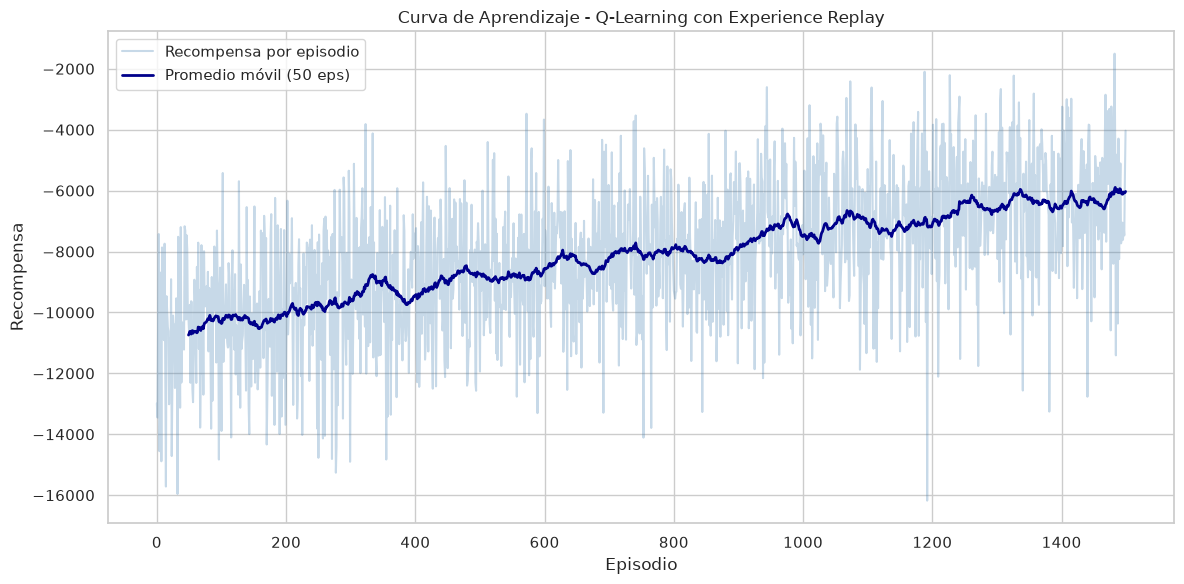

In [10]:
# Curva de Aprendizaje
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.plot(historial_recompensas, alpha=0.3, label="Recompensa por episodio", color="steelblue")

# Promedio móvil
if len(historial_recompensas) >= 50:
    window = 50
    promedio_movil = pd.Series(historial_recompensas).rolling(window=window).mean()
    plt.plot(promedio_movil, label=f"Promedio móvil ({window} eps)", color="darkblue", linewidth=2)

plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Curva de Aprendizaje - Q-Learning con Experience Replay")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
args = get_args()
ruta_modelo = os.path.join(OUT_FOLDER, "qlearning.pkl")

print(f"Cargando modelo: {ruta_modelo}")
with open(ruta_modelo, 'rb') as f:
    q_table_entrenada = pickle.load(f)

print(f"Estados en Q-table: {len(q_table_entrenada)}")

# Configuracion de evaluacion
USAR_FALLBACK = False  # True: estados no vistos -> 30s | False: estados no vistos -> ultima accion

env_eval = SumoEnvironment(
    net_file=args.net,
    route_file=args.route,
    out_csv_name=os.path.join(OUT_FOLDER, "evaluacion_final"),
    single_agent=True,
    use_gui=False,
    num_seconds=args.num_seconds,
    delta_time=5,
    yellow_time=3,
    min_green=5,
    time_to_teleport=-1,
    additional_sumo_cmd=f"-W --no-step-log --tripinfo-output {os.path.join(OUT_FOLDER, 'tripinfo.xml')}"
)

env_eval = VariableGreenWrapper(env_eval, delta_time=5)
env_eval = TrafficStateWrapper(env_eval)

obs, _ = env_eval.reset()
try:

    exploracion_nula = EpsilonGreedy(initial_epsilon=0.0, min_epsilon=0.0, decay=1.0)
    replay_buffer_eval = ReplayBuffer(buffer_size=2000)
    agente_eval = QLAgentConVisitas(
        starting_state=obs,
        state_space=env_eval.observation_space,
        action_space=env_eval.action_space,
        alpha=0.0,
        gamma=args.gamma,
        exploration_strategy=exploracion_nula,
        replay_buffer=replay_buffer_eval,
        batch_size=64,
        update_freq=4
    )
    agente_eval.q_table = q_table_entrenada

    DURACIONES = VariableGreenWrapper.DURACIONES
    N_ACCIONES = len(DURACIONES)

    def elegir_accion(q_table, estado, n_acciones, ultima_accion):
        if estado in q_table:
            return int(np.argmax(q_table[estado]))
        if USAR_FALLBACK:
            return n_acciones // 2  # 30s: accion de emergencia
        return ultima_accion  # mantener ultima duracion

    modo = "FALLBACK (30s)" if USAR_FALLBACK else "ULTIMA ACCION"
    print(f"Ejecutando evaluacion en modo: {modo}")

    done = False
    ultima_accion = N_ACCIONES // 2  # inicial: 30s
    datos_recolectados = []

    while not done:
        estado_actual = tuple(agente_eval.state)
        accion = elegir_accion(agente_eval.q_table, estado_actual, N_ACCIONES, ultima_accion)
        ultima_accion = accion  # guardar para siguiente paso
        next_obs, reward, terminated, truncated, info = env_eval.step(accion)

        datos_recolectados.append(info)
        agente_eval.state = next_obs

        if env_eval.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
            tiempo_final = env_eval.unwrapped.sim_step
            print(f"Evaluacion completada. Red vaciada en {tiempo_final:.1f}s")
            break

        done = terminated or truncated

finally:
    env_eval.close()

df_metricas = pd.DataFrame(datos_recolectados)
ruta_csv = os.path.join(OUT_FOLDER, "metricas.csv")
os.makedirs(OUT_FOLDER, exist_ok=True)
df_metricas.to_csv(ruta_csv, index=False)

print(f"CSV exportado: {ruta_csv}")
print(f"XML generado: {os.path.join(OUT_FOLDER, 'tripinfo.xml')}")

Cargando modelo: resultados/qlearning.pkl
Estados en Q-table: 269
Ejecutando evaluacion en modo: ULTIMA ACCION
Evaluacion completada. Red vaciada en 4045.0s
CSV exportado: resultados/metricas.csv
XML generado: resultados/tripinfo.xml


In [14]:
df_metricas = pd.read_csv(os.path.join(OUT_FOLDER, "metricas.csv"))
print(f"Registros cargados: {len(df_metricas)}")

Registros cargados: 267


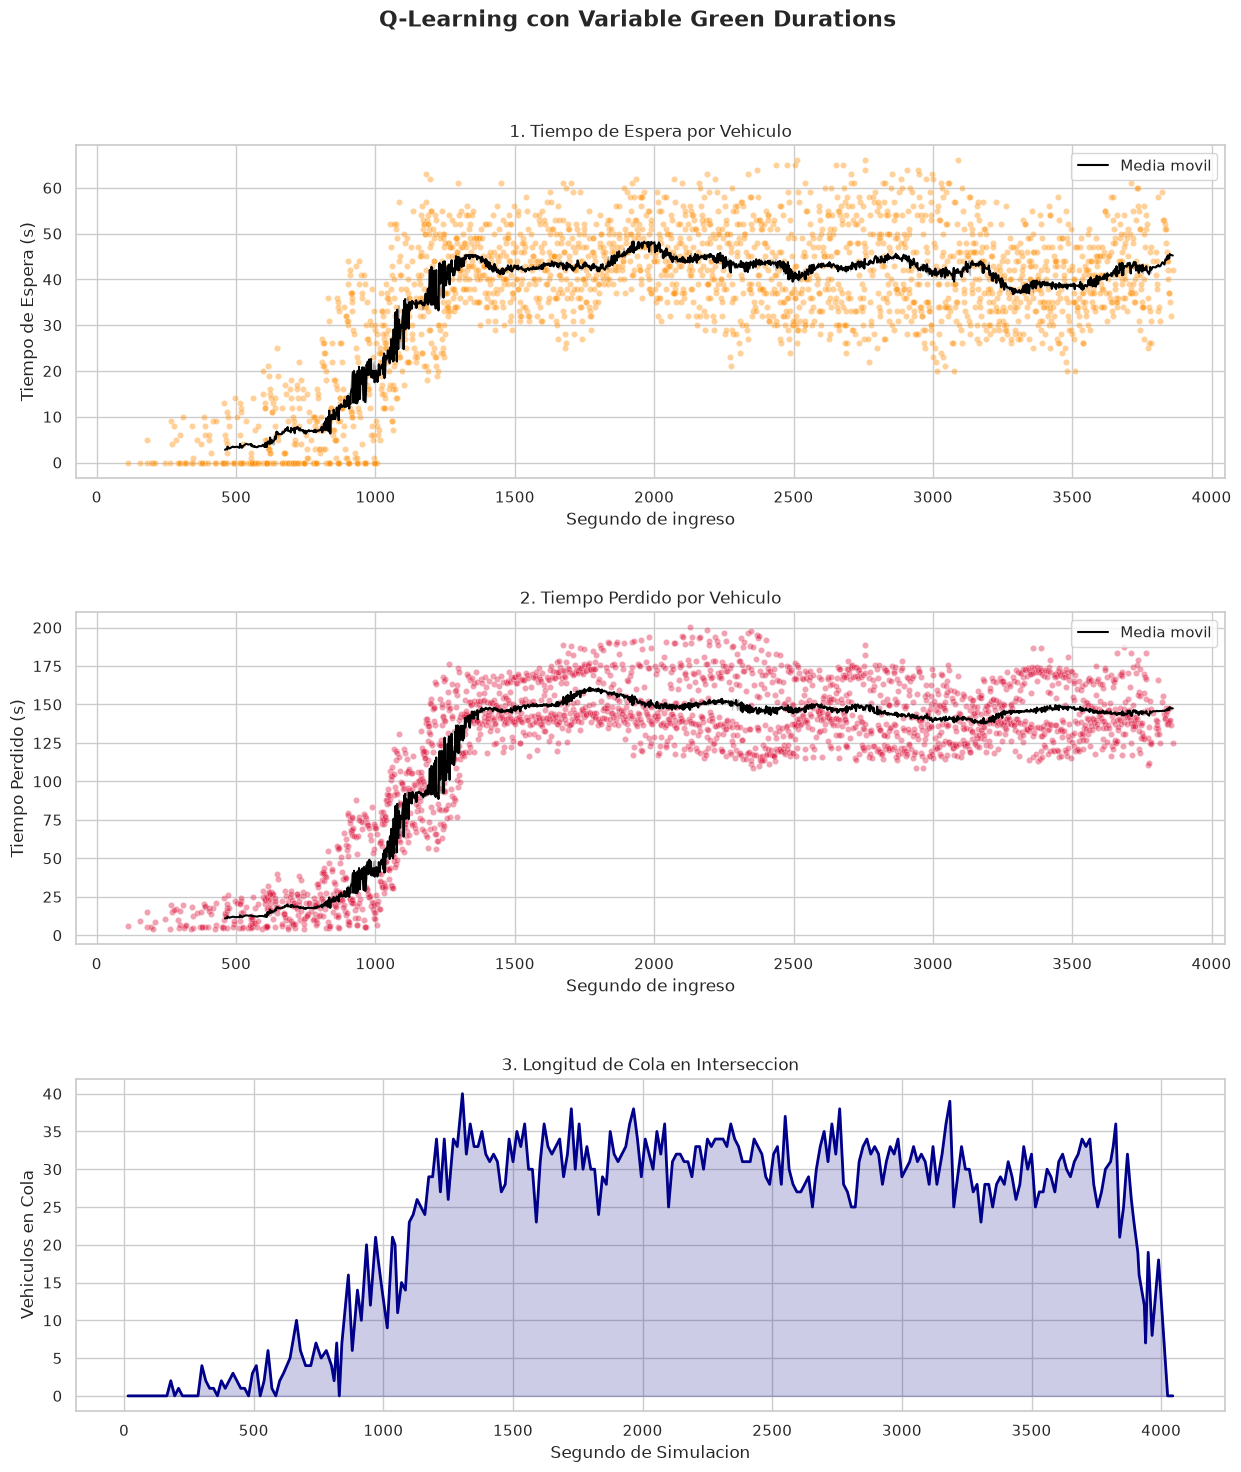

In [15]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

ruta_xml = os.path.join(OUT_FOLDER, "tripinfo.xml")
df_trips = pd.read_xml(ruta_xml)

for col in ['depart', 'waitingTime', 'timeLoss']:
    df_trips[col] = pd.to_numeric(df_trips[col])

fig, axs = plt.subplots(3, 1, figsize=(14, 15))
fig.tight_layout(pad=6.0)
fig.suptitle('Q-Learning con Variable Green Durations', fontsize=16, fontweight='bold', y=1.02)

sns.scatterplot(x=df_trips['depart'], y=df_trips['waitingTime'], alpha=0.4, color='darkorange', s=20, ax=axs[0])
sns.lineplot(x=df_trips['depart'], y=df_trips['waitingTime'].rolling(50).mean(), color='black', label='Media movil', ax=axs[0])
axs[0].set_title("1. Tiempo de Espera por Vehiculo")
axs[0].set_xlabel("Segundo de ingreso")
axs[0].set_ylabel("Tiempo de Espera (s)")
axs[0].legend()

sns.scatterplot(x=df_trips['depart'], y=df_trips['timeLoss'], alpha=0.4, color='crimson', s=20, ax=axs[1])
sns.lineplot(x=df_trips['depart'], y=df_trips['timeLoss'].rolling(50).mean(), color='black', label='Media movil', ax=axs[1])
axs[1].set_title("2. Tiempo Perdido por Vehiculo")
axs[1].set_xlabel("Segundo de ingreso")
axs[1].set_ylabel("Tiempo Perdido (s)")
axs[1].legend()

axs[2].plot(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', linewidth=2)
axs[2].fill_between(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', alpha=0.2)
axs[2].set_title("3. Longitud de Cola en Interseccion")
axs[2].set_xlabel("Segundo de Simulacion")
axs[2].set_ylabel("Vehiculos en Cola")

plt.show()

In [15]:
for col in ['waitingTime', 'timeLoss', 'routeLength', 'duration']:
    df_trips[col] = pd.to_numeric(df_trips[col])

df_trips['velocidad_kmh'] = (df_trips['routeLength'] / df_trips['duration']) * 3.6

promedio_espera = df_trips['waitingTime'].mean()
maximo_espera = df_trips['waitingTime'].max()
promedio_perdido = df_trips['timeLoss'].mean()
maximo_perdido = df_trips['timeLoss'].max()
velocidad_media = df_trips['velocidad_kmh'].mean()
total_vehiculos = len(df_trips)
cola_promedio = df_metricas['system_total_stopped'].mean()
cola_maxima = df_metricas['system_total_stopped'].max()

print("=" * 50)
print("  METRICAS: Q-Learning con Variable Green Durations")
print("=" * 50)
print("\n--- Rendimiento General ---")
print(f"Total de vehiculos procesados : {total_vehiculos}")
print(f"Velocidad promedio del sistema: {velocidad_media:.2f} km/h")

print("\n--- Demora Vehicular ---")
print(f"Tiempo de espera promedio     : {promedio_espera:.2f} s")
print(f"Tiempo de espera MAXIMO       : {maximo_espera:.2f} s")
print(f"Tiempo perdido promedio       : {promedio_perdido:.2f} s")
print(f"Tiempo perdido MAXIMO         : {maximo_perdido:.2f} s")

print("\n--- Ocupacion Interseccion ---")
print(f"Longitud de cola promedio     : {cola_promedio:.2f} vehiculos")
print(f"Longitud de cola MAXIMA       : {cola_maxima} vehiculos")
print("=" * 50)

display(df_trips[['id', 'depart', 'duration', 'waitingTime', 'timeLoss']].head())

  METRICAS: Experimento 3 - Q-Learning Doble Recompensa

--- Rendimiento General ---
Total de vehiculos procesados : 2418
Velocidad promedio del sistema: 15.36 km/h

--- Demora Vehicular ---
Tiempo de espera promedio     : 36.89 s
Tiempo de espera MAXIMO       : 71.00 s
Tiempo perdido promedio       : 122.10 s
Tiempo perdido MAXIMO         : 199.35 s

--- Ocupacion Interseccion ---
Longitud de cola promedio     : 23.14 vehiculos
Longitud de cola MAXIMA       : 38 vehiculos


,id,depart,duration,waitingTime,timeLoss
0,veh_0,112.0,50.0,0.0,5.63
1,veh_1,154.0,56.0,1.0,9.13
2,veh_3,179.0,53.0,0.0,6.01
3,veh_2,179.0,60.0,6.0,15.12
4,veh_4,195.0,50.0,0.0,5.72
